<h2>Clustering Analysis - Part 2</h2>
 <ul>
    <li>Hierarchical Clustering</li>
    <li>Gaussian Mixture Models</li>
 </ul>
 

<h2>1. Hierarchical Clustering</h2>

<h3>1.1. Concept </h3><br/>
There are two types of Hierarchical clustering methods: 
    <ul>
    <li>Agglomerative: Bottom up</li>
    <li>Divisive: Top bottom</li>
    </ul>

Agglomerative Hierarchical clustering is a clustering approach seeking to <span style="color:blue">build a hierarchy of clusters</span> using a <span style="color:blue">bottom-up proximity</span> between data points. In a way, HC finds <span style="color:blue">all existing relationships</span> between data points.

<img src="Media/HC_illustration.png"/>

Approach: <b style="color:blue">Find the closest groupings of data points from n clusters to 1 cluster.</b>

<ol>
 <li>Given n data points</li>
 <li>Initialise n clusters</li>
 <li>Merge the closest clusters one at a time</li>
    <li>Until they all merge into a single cluster</li>
    <li>Thus building the dendogram tree (of relationships)</li>
</ol>

<img src="Media/table_clustering.png"/>

<img src="Media/HC_alg.jpg"/>

<h3>1.2. Finding the distance between a cluster and a data point (or cluster) - Linkage Methods</h3>



How does one measure the distance between a 1-data point cluster and a n-data point cluster?

<img src="Media/linkage_methods.png"/>

<h3>1.3. Implementation - HC</h3>

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore') #ignore warnings
#load the dataset
df = pd.read_csv('datasets/OLART_customers.csv')
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


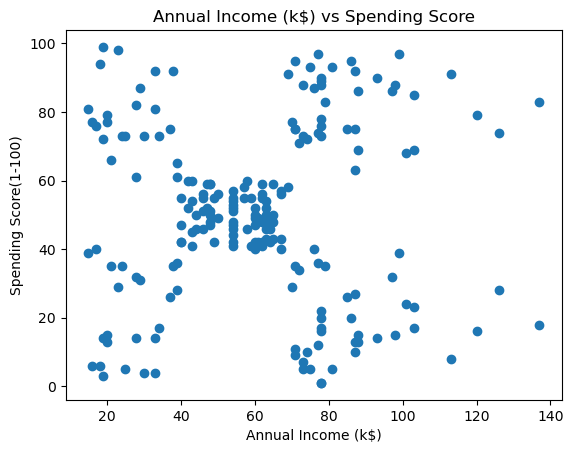

In [13]:
#select data of interest
sub_df = df.iloc[:,[3,4]] #Annual Income against Spending Score
x_1 = sub_df['Annual Income (k$)']
x_2 = sub_df['Spending Score (1-100)']

#plotting the data of interest
plt.figure()
plt.scatter(x_1,x_2)
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score(1-100)')
plt.title('Annual Income (k$) vs Spending Score')
plt.show()

In [14]:
#Dendogram formation
from scipy.cluster.hierarchy import ward, dendrogram
import scipy.cluster.hierarchy as sch
import matplotlib.pyplot as plt

linkage_matrix = sch.linkage(sub_df, method='average', metric='euclidean')


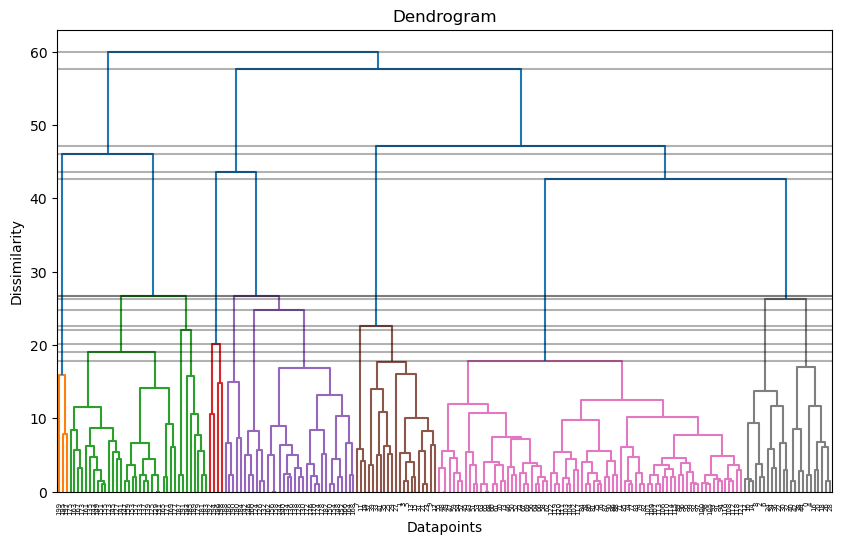

In [15]:
plt.figure(figsize=(10,6))
dendrogram = sch.dendrogram(linkage_matrix)
z = linkage_matrix[:,2]
for i in range(1,16):
    rng = [z[-i],z[-i]]
    dom = [0,40000]
    plt.plot(dom,rng,'black', alpha=0.3)

plt.title('Dendrogram')
plt.xlabel('Datapoints')
plt.ylabel('Dissimilarity')
plt.show()

<h3>1.4 Find the Optimal K from the dendogram tree</h3>

Natural clusters: <b style="color:blue">"Look for points in the dendogram where the distances between clusters suddenly increases"</b>

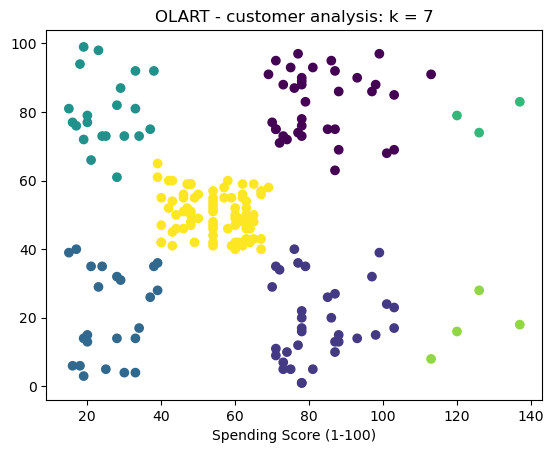

In [16]:
from sklearn.cluster import AgglomerativeClustering

k_choice = 7
hc = AgglomerativeClustering(n_clusters=k_choice, linkage='average').fit(sub_df)
clusterIds = hc.labels_
plt.figure()
plt.xlabel(sub_df.columns[0])
plt.xlabel(sub_df.columns[1])
plt.scatter(x_1,x_2,c=clusterIds)
plt.title('OLART - customer analysis: k = %d'%k_choice)
plt.show()

<h3>1.4. K-Means vs Hierarchical Clustering</h3>

<table>
    <tr>
        <td>K-Means</td><td>HC</td>
    </tr>
    <tr>
        <td>Works well for spherical cluster groups</td><td>Reproducible results - same tree all the time</td>
    </tr>
    <tr>
        <td>Computationally efficient (good for large datasets)</td><td>More adaptable to any cluster shape</td>
    </tr>
    <tr>
        <td>Require apriori knowledge of k-clusters</td><td>Computationally expensive for large datasets</td>
    </tr>
    <tr>
        <td></td><td>More informative and interpretable</td>
    </tr>
</table>


<p style="color:blue">Which to Choose? - Guidelines</p>
<ul>
    <li>If there is a specific number of clusters in the data, but the group they belong is unknown,  <b>K-Means</b>
    </li>
    <li>If the number of cluster group is unknown and the dataset is not so large, <b>Hierarchical clustering</b>
    </li>
    <li>If the dataset is too large, <b>K-Means</b></li>
    <li>If there is a need for in depth interpretation of data grouping, <b>Hierarchical clustering</b></li>
</ul>

<h2>2. Gaussian Mixture Models</h2>

<h3>2.1. Concept</h3><br/>
Gaussian Mixture Model (GMM) Clustering is a soft clustering technique that assign a probability of belongingness to data points across multiple clusters. <b style="color:blue">Data points belong to each cluster to varying degrees.</b>

<img src="Media/black-and-blue-dress.jpg" width="300px"/>

<img src="Media/gmm.png"/>

Approach: <b style="color:blue">We attempt to fit a Gaussian distribution to each cluster</b>, and thus determines the degree of belongingness to each datapoint.

Assumption: Each cluster is spherical or elliptical in shape and can be characterised by centroid (mean: $\mu_k$) and a variance 
$\sigma_k^2$. However, these <span style="color:blue">parameters are unknown and needs to be determined</span>. <b>!!! Notice the similarity with K-Means</b>

<h3>2.2. Distribution Estimation and the Expected Maximisation Algorithm</h3>

In [17]:
import numpy as np
import math
import matplotlib.pyplot as plt
# 1D data with N = 100 samples
X = np.array([ 0.4690433 ,  1.77247772, -0.79937833,  2.08347278,  0.96008571,
                0.84984587,  2.53514641, -1.77954757, -0.2197194 , -0.24392515,
               -1.45156281,  0.05793749,  1.22118967,  0.69298749, -1.95318449,
                0.46780091,  1.48841197,  0.03489486, -0.71973614,  0.78253223,
               -1.10623475, -1.39394697,  1.43624876,  0.0722706 ,  1.62888107,
               -0.61214466, -2.86427397, -1.01435684,  0.18012821, -0.43215255,
                1.40345509,  0.40500954, -0.1878166 ,  1.39892911, -0.30331199,
               -1.24989628,  0.05717373,  0.20798511, -0.75087319, -0.96573914,
               -0.83499918,  0.95337156, -0.03423916, -0.2720539 ,  0.852107  ,
                0.36567677,  1.56131278,  0.50956683, -0.20242891, -0.50132433,
               -0.39382268, -0.99104849, -1.11567828, -0.21453752,  0.49848449,
               -1.09310205, -0.09755406,  0.77719942, -1.18284674, -0.02979667,
               -0.54815865,  1.2200912 , -0.51472699,  0.83554114, -1.62354525,
               -1.03256075,  0.800314  , -0.41924884, -0.77253838, -0.32138824,
                1.22731845, -0.30567561,  0.19722008, -0.46858797,  0.56092996,
               -1.66687179,  0.50654635,  1.68834199, -0.12608541,  1.88398685,
               -1.02705767, -1.0139658 ,  0.94250101, -0.2120914 , -0.32842348,
                0.15071674,  0.21345239, -0.23936087, -1.35388172, -0.60518554,
                0.61064511,  0.11129081,  1.18438721,  0.51317973, -2.59507755,
               -1.08846815, -2.10072134,  0.10113415, -0.75070778,  0.45416333])

In [18]:
mean = np.mean(X)
variance = np.var(X,ddof=1)
print("mean = ",mean, "\nvariance = ",variance)

mean =  -0.05200175000000003 
variance =  1.086265726774446


<h3>2.2.1. How do we determine a Gaussian distribution?</h3>

Estimate the mean of the data: 
$$
\hat{\mu} = \frac{1}{N}\sum_{i=1}^{N}x_i
$$

Estimate the mean of the data: 
$$
\hat{\sigma}^2 = \frac{1}{N-1}\sum_{i=1}^{N}(x_i-\hat{\mu})^2
$$

The probability density function equal: 
$$
PDF(x,\hat{\mu}, \hat{\sigma}^2) = \frac{1}{\sqrt{2\pi\hat{\sigma}^2}}exp([-\frac{(\hat{\mu}-x)^2}{2\hat{\sigma}^2}])
$$

In [19]:
# create hypothesis function
def hypothesis(x,mean,var):
    C = 1/np.sqrt(2*np.pi*var)
    return C*np.exp(-((mean-x)**2)/(2*var))

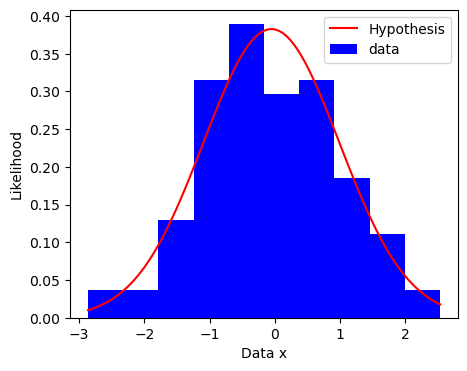

In [20]:
plt.figure(figsize=(5,4))
# evaluate hypothesis at every point between smallest and largest x
domain = np.linspace(np.min(X),np.max(X),num=100)
hyp = hypothesis(domain,mean,variance)
plt.plot(domain,hyp,'red',label='Hypothesis')

# plot histogram of data   
plt.hist(X,density=True,color='blue',label='data')
plt.legend()
plt.xlabel('Data x')
plt.ylabel('Likelihood')
plt.show()

<b>This concept can be extended to n-dimensions!!!</b>

<img src="Media/2d_bell.jpg" width="500px"/>

$$
 \mu = \begin{bmatrix}
 \mu_1\\
 \mu_2\\
 ..\\
 \mu_n
 \end{bmatrix},\Sigma = \begin{bmatrix}
    \sigma_{1}^2 & \sigma_{12} & \cdots & \sigma_{1n} \\
    \sigma_{21} & \sigma_{2}^2 & \cdots & \sigma_{2n} \\
    \vdots & \vdots & \ddots & \vdots \\
    \sigma_{n1} & \sigma_{n2} & \cdots & \sigma_{n}^2
\end{bmatrix}, P(x,\mu, \Sigma) = \frac{1}{(2\pi)^{n/2} |\Sigma|^{1/2}} \exp\left( -\frac{1}{2} (x - \mu)^T \Sigma^{-1} (x - \mu) \right)
$$

<h3>2.2.2. How do we find the best Gaussian centroids?</h3>

GMM aims assign a level of belongingness to each datapoint across multiple clusters.

$$
 p(x|\theta=[\mu,\Sigma,w])=\sum_{k=1}^{K}w_kp(x,\mu_k,\Sigma_k)\equiv \text{a datapoint belongs to each cluster to varying degree}
$$

<b>Optimisation problem</b>: <span style="color:blue">Find $\mu, w, \Sigma$ that will maximise the likelihood that all datapoints follow this distribution.</span>


$$
 \text{Maximise }C(\theta)= P(Event(x_1) \cap Event(x_2)\cap..\cap Event(x_n))= P(x_1|\theta).P(x_2|\theta)...P(x_n|\theta) = \prod_{i=1}^{N}P(x_i|\theta)
$$

In [10]:
"Maximum Likelihood Estimation"

'Maximum Likelihood Estimation'

$$
C(\theta)\equiv L(\theta)=log(\prod_{i=1}^{N}P(x_i|\theta))
$$

This cost function is solved using <span style="color:blue">numerical optimisation theory (gradient-methods) or the Expectation-Maximisation algorithm</span>.

<h3>2.2.3. Expectation-Maximisation algorithm</h3>

<ol>
    <li>Choose K</li>
    <li>Randomly Initialise all Gaussians: mean vector and covaraince matrix</li>
    <li>Compute the likelihood for each datapoint</li>
    <li>Compute the posterior for each Gaussian distribution parameter set:</li>
    $$
    P(\mu_k,\Sigma_k|x_i) = \frac{P(x_i|\mu_k,\Sigma_k)P(k)}{\sum_{k=1}^{K}P(x_i|\mu_k,\Sigma_k)P(k)}
    $$
</ol>

<img src="Media/steps.png"/>

<b>The algorithm repeats until there is no further improvement.</b>

<h3>2.3. Implementation</h3>



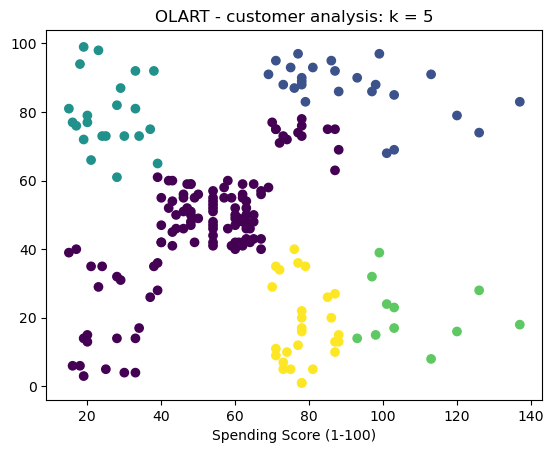

In [24]:
from sklearn.mixture import GaussianMixture
k_choice = 5
# Create the GMM instance
GMM = GaussianMixture(n_components=k_choice, random_state=23)
GMM.fit(sub_df)
clusterIds= GMM.predict(sub_df)
plt.figure()
plt.xlabel(sub_df.columns[0])
plt.xlabel(sub_df.columns[1])
plt.scatter(x_1,x_2,c=clusterIds)
plt.title('OLART - customer analysis: k = %d'%k_choice)
plt.show()

<h3>2.4. Pros and Cons</h3>

<b>Pros</b>
<ul>
    <li>Provides probability estimates rather than hard assignments</li>
    <li>Clusters can be of any ellipsoidal shape, not just circular ones.</li>
</ul>

<b>Cons</b>
<ul>
    <li>The number of clusters K needs to be specified before</li>
    <li>Requires assumption of Gaussian (Normal) distributions across dimensions</li>
</ul>

<table>
  <tr>
    <th>Criteria</th>
    <th>K-Means</th>
    <th>Gaussian Mixture Models (GMMs)</th>
    <th>Hierarchical Clustering (HC)</th>
  </tr>
  <tr>
    <td>Data Distribution</td>
    <td>Well-separated, spherical clusters</td>
    <td>Complex or overlapping clusters</td>
    <td>No specific assumptions, adapts to different data distributions</td>
  </tr>
  <tr>
    <td>Cluster Shape</td>
    <td>Spherical clusters</td>
    <td>Spherical and ellipsoidal clusters</td>
    <td>No restrictions on cluster shape</td>
  </tr>
  <tr>
    <td>Cluster Assignment</td>
    <td>Hard assignment (each point belongs to only one cluster)</td>
    <td>Soft assignment (points can belong to multiple clusters with probabilities)</td>
    <td>Can perform both hard and soft clustering</td>
  </tr>
  <tr>
    <td>Number of Clusters</td>
    <td>Need to specify the number of clusters (K)</td>
    <td>Need to specify the number of clusters (K)</td>
    <td>Can determine the number of clusters using dendrogram or other methods</td>
  </tr>
  <tr>
    <td>Computational Efficiency</td>
    <td>Fast and scalable, suitable for large datasets</td>
    <td>Can be slower than K-Means, especially for large datasets</td>
    <td>Can be computationally intensive, especially for large datasets or single-linkage</td>
  </tr>
</table>